In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, Attention, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [11]:
# Cấu hình tối ưu cho RTX 3050 (4GB VRAM)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ Đã tìm thấy GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)

✓ Đã tìm thấy GPU: /physical_device:GPU:0


In [64]:
# Đường dẫn trên máy của bạn
DATA_PATH = r"C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\data\finally\final_dataset_target_6h.csv"
MODEL_DIR = r"C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\models\lstm"
os.makedirs(MODEL_DIR, exist_ok=True)

# THAM SỐ HUẤN LUYỆN
WINDOW_SIZE = 48  # Nhìn lại 24h
HORIZON = 6       # Dự báo cho 6h sau
BATCH_SIZE = 64   # Giữ 32 để ổn định Gradient trên RTX 3050
EPOCHS = 100

# DANH SÁCH ĐẶC TRƯNG ĐÚNG THEO YÊU CẦU (16 đặc trưng)
SELECTED_FEATURES = [
    'aqi_current', 'pm25', 'wind_speed', 'o3', 'hour', 'hour_sin', 'hour_cos', 'aod',
    'temperature', 'pressure', 'humidity', 'wind_dir', 'pm10', 'dust', 'no2', 'precipitation'
]

TARGET_COL = 'aqi_diff_6h' # Dự báo chênh lệch để đạt R2 cao

In [65]:
def build_sequences(df, feature_cols, target_col, window_size):
    X, y = [], []
    for village, group in df.groupby('village'):
        group = group.sort_values('timestamp').reset_index(drop=True)
        feat_data = group[feature_cols].values
        target_data = group[target_col].values
        for i in range(len(group) - window_size):
            X.append(feat_data[i : i + window_size])
            y.append(target_data[i + window_size - 1]) 
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)



In [66]:
print(f"📥 Đang tải dữ liệu: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Tạo các biến thời gian nếu chưa có trong CSV
if 'hour' not in df.columns:
    df['hour'] = df['timestamp'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 🚀 TÍNH TOÁN TARGET (CHÊNH LỆCH)
df['aqi_diff_6h'] = df['target_aqi_6h'] - df['aqi_current']

# Chia dữ liệu (Temporal Split)
train_df = df[df['timestamp'] < '2025-08-01'].copy()
val_df   = df[(df['timestamp'] >= '2025-08-01') & (df['timestamp'] < '2026-01-01')].copy()
test_df  = df[df['timestamp'] >= '2026-01-01'].copy()

# Scaling
scaler_x, scaler_y = StandardScaler(), StandardScaler()
train_df.loc[:, SELECTED_FEATURES] = scaler_x.fit_transform(train_df[SELECTED_FEATURES])
val_df.loc[:, SELECTED_FEATURES]   = scaler_x.transform(val_df[SELECTED_FEATURES])
test_df.loc[:, SELECTED_FEATURES]  = scaler_x.transform(test_df[SELECTED_FEATURES])

train_df.loc[:, [TARGET_COL]] = scaler_y.fit_transform(train_df[[TARGET_COL]])
val_df.loc[:, [TARGET_COL]]   = scaler_y.transform(val_df[[TARGET_COL]])
test_df.loc[:, [TARGET_COL]]  = scaler_y.transform(test_df[[TARGET_COL]])

X_train, y_train = build_sequences(train_df, SELECTED_FEATURES, TARGET_COL, WINDOW_SIZE)
X_val, y_val     = build_sequences(val_df, SELECTED_FEATURES, TARGET_COL, WINDOW_SIZE)
X_test, y_test   = build_sequences(test_df, SELECTED_FEATURES, TARGET_COL, WINDOW_SIZE)

print(f"✅ Dữ liệu sẵn sàng. X_train: {X_train.shape}")

📥 Đang tải dữ liệu: C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\data\finally\final_dataset_target_6h.csv
✅ Dữ liệu sẵn sàng. X_train: (248814, 48, 16)


In [67]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)

    # Lớp BiLSTM 1
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # Lớp BiLSTM 2
    x2 = Bidirectional(LSTM(32, return_sequences=True))(x)
    x2 = BatchNormalization()(x2)

    # Cơ chế Attention
    attn = Attention()([x2, x2])
    
    # Trích xuất trạng thái cuối cùng
    last_step = attn[:, -1, :] 

    z = Dense(32, activation="relu")(last_step)
    outputs = Dense(1)(z)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="huber")
    return model

model = build_model((WINDOW_SIZE, len(SELECTED_FEATURES)))
model.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 48, 16)]     0           []                               
                                                                                                  
 bidirectional_14 (Bidirectiona  (None, 48, 128)     41472       ['input_9[0][0]']                
 l)                                                                                               
                                                                                                  
 batch_normalization_14 (BatchN  (None, 48, 128)     512         ['bidirectional_14[0][0]']       
 ormalization)                                                                                    
                                                                                            

In [68]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
3888/3888 [==============================] - 109s 27ms/step - loss: 0.1215 - val_loss: 0.3043 - lr: 0.0010
Epoch 2/100
3888/3888 [==============================] - 105s 27ms/step - loss: 0.0519 - val_loss: 0.3185 - lr: 0.0010
Epoch 3/100
3888/3888 [==============================] - 103s 26ms/step - loss: 0.0351 - val_loss: 0.3178 - lr: 0.0010
Epoch 4/100
3888/3888 [==============================] - 104s 27ms/step - loss: 0.0271 - val_loss: 0.3208 - lr: 0.0010
Epoch 5/100
3888/3888 [==============================] - 104s 27ms/step - loss: 0.0224 - val_loss: 0.3327 - lr: 0.0010
Epoch 6/100
3888/3888 [==============================] - 104s 27ms/step - loss: 0.0193 - val_loss: 0.3221 - lr: 0.0010
Epoch 7/100
3888/3888 [==============================] - 104s 27ms/step - loss: 0.0135 - val_loss: 0.3280 - lr: 5.0000e-04
Epoch 8/100
3888/3888 [==============================] - 103s 26ms/step - loss: 0.0124 - val_loss: 0.3255 - lr: 5.0000e-04
Epoch 9/100
3888/3888 [=================

In [69]:
# 1. Dự báo chênh lệch
y_pred_diff_scaled = model.predict(X_test)
y_pred_diff = scaler_y.inverse_transform(y_pred_diff_scaled).flatten()
y_test_diff = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 2. Lấy AQI hiện tại để cộng dồn
aqi_current_idx = SELECTED_FEATURES.index('aqi_current')
X_test_unscaled = scaler_x.inverse_transform(X_test[:, -1, :])
aqi_current_val = X_test_unscaled[:, aqi_current_idx]

# 3. AQI Thực tế = Hiện tại + Chênh lệch dự báo
y_pred_real = aqi_current_val + y_pred_diff
y_test_real = aqi_current_val + y_test_diff

# Tính Metrics
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("="*40)
print(f"🎯 KẾT QUẢ VỚI 16 FEATURES YÊU CẦU")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")
print("="*40)

1496/1496 [==============================] - 13s 8ms/step
🎯 KẾT QUẢ VỚI 16 FEATURES YÊU CẦU
MAE  : 20.51
RMSE : 26.81
R2   : 0.6349


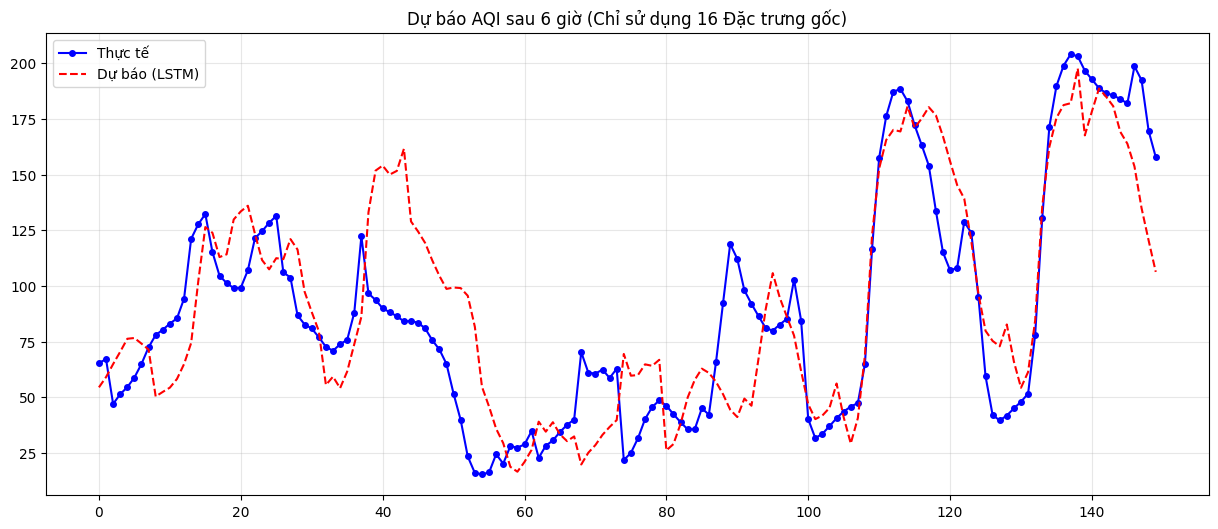

In [70]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:150], label="Thực tế", color="blue", marker="o", markersize=4)
plt.plot(y_pred_real[:150], label="Dự báo (LSTM)", color="red", linestyle="--")
plt.title("Dự báo AQI sau 6 giờ (Chỉ sử dụng 16 Đặc trưng gốc)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [71]:
metadata = {
    "model_type": "LSTM_Attention",
    "metrics": {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)},
    "config": {"window": WINDOW_SIZE, "horizon": HORIZON, "features": SELECTED_FEATURES}
}

with open(os.path.join(MODEL_DIR, "metadata_lstm.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("🚀 Huấn luyện và lưu mô hình hoàn tất!")

🚀 Huấn luyện và lưu mô hình hoàn tất!
